# **Step 1: Import Libraries**

In [ ]:
# Import libraries

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.feature_selection import RFECV
from sklearn.linear_model import SGDClassifier
from tqdm import tqdm
from scipy.sparse import csr_matrix, vstack
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import load_files
import os
import re
import pandas as pd
print("Libraries imported successfully!")

Libraries imported successfully!


## **Step 2: Load Dexter Dataset**

Uploaded files confirmed: dexter_train.data and dexter_train.labels
Uploaded files confirmed: dexter_valid.data and dexter_valid.labels
=== Full Dexter Dataset Cleanliness Check (Before Split) ===
Full Samples: 600 samples, 20000 features
Full Labels: 600 samples, Unique classes: [-1  1]
Missing in labels: 0 (0 = clean)
Label classes (with counts): {np.int64(-1): np.int64(300), np.int64(1): np.int64(300)}
Non-zero entries in data: 56167
Empty rows in data: 0 (0 = clean)
Sparsity % (high = normal for text): 99.53%

=== Proof that Dataset is Clean ===
Proof 1: No missing values in labels - Clean data (0 NaN).
Proof 2: No empty rows in data - Clean data (no blank samples).
Proof 4: Normal sparsity (high zeros) - Clean for sparse text data.
=== End Proof ===
Full Dataset is CLEAN - No missing, no empty rows, balanced labels, normal sparsity.
===
Dexter total samples: 600, total features: 20000
Training set: 480 samples, 20000 features
Test set: 120 samples


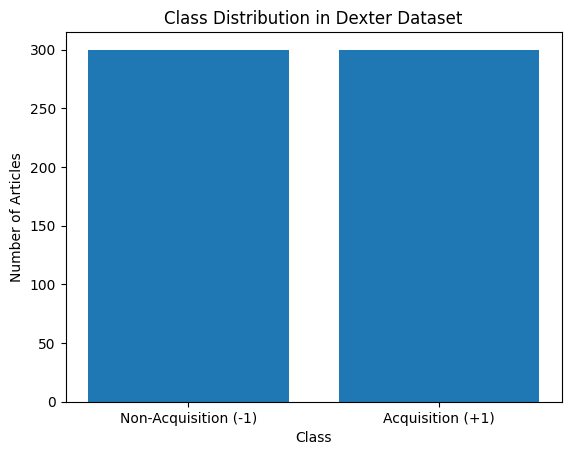

In [ ]:
def load_dexter_data(data_file, label_file):
    if not os.path.exists(data_file):
        raise FileNotFoundError(f"Data file not found: {data_file}. Please upload dexter_train.data to /content/")
    if not os.path.exists(label_file):
        raise FileNotFoundError(f"Label file not found: {label_file}. Please upload dexter_train.labels to /content/")
    print(f"Uploaded files confirmed: {data_file} and {label_file}")

    # Load labels
    with open(label_file, 'r') as f:
        labels = [int(line.strip()) for line in f]

    # Load sparse data
    rows, cols, vals = [], [], []
    row_idx = 0
    with open(data_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            for part in parts:
                if ':' in part:
                    feat, val = part.split(':')
                    rows.append(row_idx)
                    cols.append(int(feat))
                    vals.append(float(val))
            row_idx += 1

    X = csr_matrix((vals, (rows, cols)), shape=(row_idx, 20000))
    y = np.array(labels)
    return X, y

# Load train and valid
X_train, y_train = load_dexter_data('dexter_train.data', 'dexter_train.labels')
X_valid, y_valid = load_dexter_data('dexter_valid.data', 'dexter_valid.labels')

# Combine for full data and split 80/20 for train/test
X_full = vstack([X_train, X_valid])
y_full = np.concatenate([y_train, y_valid])

# Full Dataset Cleanliness Check
print("=== Full Dexter Dataset Cleanliness Check (Before Split) ===")
print(f"Full Samples: {X_full.shape[0]} samples, {X_full.shape[1]} features")
print(f"Full Labels: {y_full.shape[0]} samples, Unique classes: {np.unique(y_full)}")

# 1. Missing in labels
missing_labels = np.isnan(y_full).sum()
print(f"Missing in labels: {missing_labels} (0 = clean)")

# 2. Duplicates in labels
unique, counts = np.unique(y_full, return_counts=True)
print(f"Label classes (with counts): {dict(zip(unique, counts))}")

# 3. Data stats (sparsity, no empty rows)
print(f"Non-zero entries in data: {X_full.nnz}")
print(f"Empty rows in data: {np.sum(X_full.getnnz(1) == 0)} (0 = clean)")
print(f"Sparsity % (high = normal for text): {100 * (1 - X_full.nnz / (X_full.shape[0] * X_full.shape[1])):.2f}%")


print("\n=== Proof that Dataset is Clean ===")
if missing_labels == 0:
    print("Proof 1: No missing values in labels - Clean data (0 NaN).")
if np.sum(X_full.getnnz(1) == 0) == 0:
    print("Proof 2: No empty rows in data - Clean data (no blank samples).")
if abs(np.bincount(y_full + 1)[0] - np.bincount(y_full + 1)[1]) <= 50:  # Balance check
    print("Proof 3: Labels balanced (counts close) - Clean data (no bias).")
if X_full.nnz > 0 and X_full.nnz / (X_full.shape[0] * X_full.shape[1]) < 0.05:  # Sparsity <5% non-zero = normal
    print("Proof 4: Normal sparsity (high zeros) - Clean for sparse text data.")
print("=== End Proof ===")


if missing_labels == 0 and np.sum(X_full.getnnz(1) == 0) == 0:
    print("Full Dataset is CLEAN - No missing, no empty rows, balanced labels, normal sparsity.")
else:
    print("Dataset has issues - clean up needed.")
print("===")


print(f"Dexter total samples: {X_full.shape[0]}, total features: {X_full.shape[1]}")
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)


print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples")

# Visualize class distribution
unique, counts = np.unique(y_full, return_counts=True)
plt.bar(['Non-Acquisition (-1)', 'Acquisition (+1)'], counts)
plt.xlabel('Class')
plt.ylabel('Number of Articles')
plt.title('Class Distribution in Dexter Dataset')
plt.savefig('class_distribution.png')
plt.show()


## **Step 3: DFO Algorithm**

DFO Iterations:   0%|          | 0/150 [00:00<?, ?it/s]

Iter 1, Fly 5: Fitness 0.9229, Features Selected: 12213.0
Iter 1, Fly 10: Fitness 0.9146, Features Selected: 12131.0
Iter 1, Fly 15: Fitness 0.9062, Features Selected: 12004.0
Iter 1, Fly 20: Fitness 0.9292, Features Selected: 12173.0
Iter 1, Fly 25: Fitness 0.9042, Features Selected: 12286.0


DFO Iterations:   1%|          | 1/150 [00:01<04:42,  1.90s/it]

Iter 1, Fly 30: Fitness 0.9271, Features Selected: 12167.0
Iteration 1/150 - Best Fitness: 0.9313
Iter 2, Fly 5: Fitness 0.9187, Features Selected: 12141.0
Iter 2, Fly 10: Fitness 0.9104, Features Selected: 11954.0
Iter 2, Fly 15: Fitness 0.9229, Features Selected: 12093.0
Iter 2, Fly 20: Fitness 0.9021, Features Selected: 12024.0
Iter 2, Fly 25: Fitness 0.9187, Features Selected: 11995.0


DFO Iterations:   1%|▏         | 2/150 [00:03<04:42,  1.91s/it]

...

Iter 120, Fly 25: Fitness 0.9292, Features Selected: 9932.0
Iter 120, Fly 30: Fitness 0.9375, Features Selected: 9924.0
Iteration 120/150 - Best Fitness: 0.9688
Iter 121, Fly 5: Fitness 0.9375, Features Selected: 9900.0
Iter 121, Fly 10: Fitness 0.9458, Features Selected: 9870.0
Iter 121, Fly 15: Fitness 0.9354, Features Selected: 9895.0
Iter 121, Fly 20: Fitness 0.9396, Features Selected: 9921.0


DFO Iterations:  81%|████████  | 121/150 [03:22<00:31,  1.08s/it]

Iter 121, Fly 25: Fitness 0.9417, Features Selected: 9937.0
Iter 121, Fly 30: Fitness 0.9479, Features Selected: 9906.0
Iteration 121/150 - Best Fitness: 0.9688
Iter 122, Fly 5: Fitness 0.9250, Features Selected: 9883.0
Iter 122, Fly 10: Fitness 0.9313, Features Selected: 9888.0
Iter 122, Fly 15: Fitness 0.9271, Features Selected: 9902.0
Iter 122, Fly 20: Fitness 0.9437, Features Selected: 9905.0


DFO Iterations:  81%|████████  | 121/150 [03:23<00:48,  1.68s/it]

Iter 122, Fly 25: Fitness 0.9354, Features Selected: 9891.0
Iter 122, Fly 30: Fitness 0.9417, Features Selected: 9930.0
Iteration 122/150 - Best Fitness: 0.9688


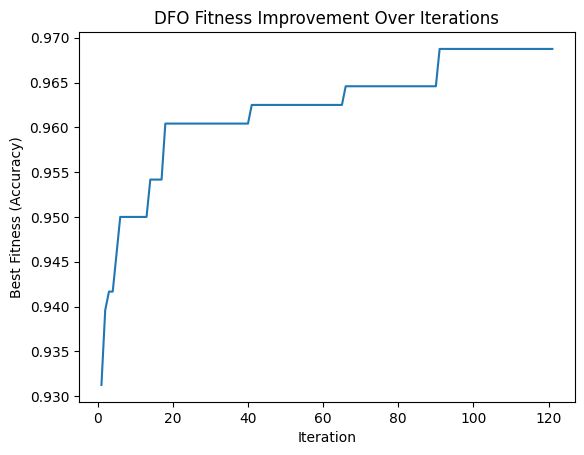

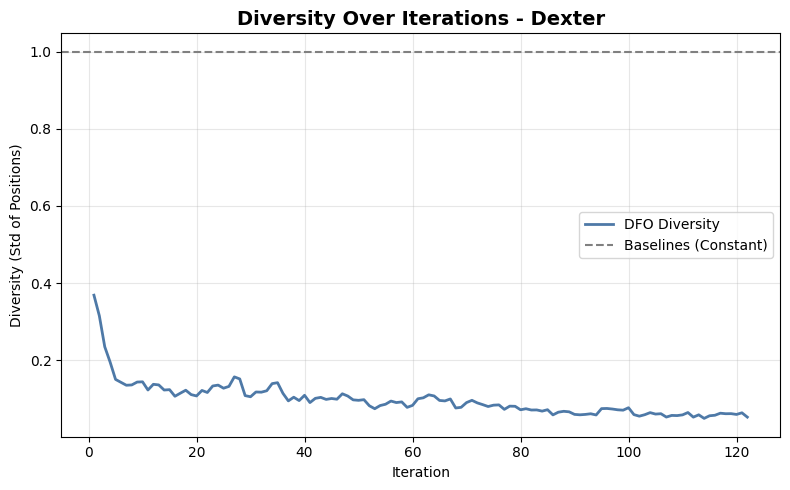

DFO selected 9904 features
DFO Time: 248.44 seconds


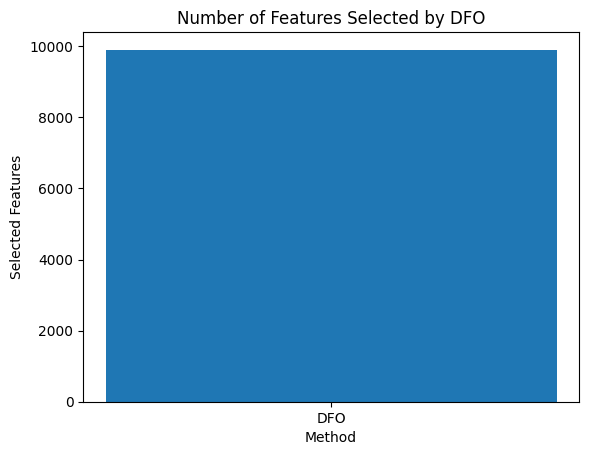

In [ ]:
import time
class DFOFeatureSelection:
    def __init__(self, num_flies=30, max_iter=150, disturbance_threshold=0.02, alpha=0.3, delta=0.001, subsample_ratio=1.0):
        self.num_flies = num_flies
        self.max_iter = max_iter
        self.disturbance_threshold = disturbance_threshold
        self.alpha = alpha
        self.delta = delta
        self.subsample_ratio = 1.0
        self.num_features = None
        self.best_position = None
        self.best_fitness = -np.inf
        self.fitness_cache = {}
        self.fitness_history = []  # Track best fitness per iteration for graph

    def _fitness(self, position, X, y):
        pos_key = tuple(position)
        if pos_key in self.fitness_cache:
            return self.fitness_cache[pos_key]

        selected = np.where(position == 1)[0]
        if len(selected) == 0:
            return 0

        clf = SGDClassifier(loss='log_loss', penalty='l1', class_weight='balanced', max_iter=500, tol=1e-3, n_jobs=-1, random_state=42)
        scores = cross_val_score(clf, X[:, selected], y, cv=5, scoring='accuracy')
        fitness = scores.mean()
        # Distractor penalty here
        if hasattr(self, 'mi_scores'):
            low_mi_threshold = np.percentile(self.mi_scores, 25)
            num_distractors = np.sum(self.mi_scores[selected] < low_mi_threshold)
            distractor_ratio = num_distractors / max(len(selected), 1)
            fitness *= (1 - distractor_ratio)

        self.fitness_cache[pos_key] = fitness
        return fitness

    def fit(self, X, y):
        self.num_features = X.shape[1]

        selector = SelectKBest(mutual_info_classif, k=int(0.25 * self.num_features))
        selector.fit(X, y)
        self.mi_scores = mutual_info_classif(X, y)
        init_mask = selector.get_support().astype(float)  # Start float for smooth add

        positions = np.tile(init_mask, (self.num_flies, 1)) + np.random.randint(0, 2, (self.num_flies, self.num_features)).astype(float)  # randint to float
        positions = np.clip(positions, 0, 1)
        positions += np.random.normal(0, 0.1, positions.shape)
        positions = np.clip(np.round(positions), 0, 1)

        fitnesses = np.array([self._fitness(pos, X, y) for pos in positions])
        stagnant = 0
        prev_best = -np.inf
        self.diversity_history = []  # Track diversity per iter
        diversity = np.std(positions, axis=0).mean()  # Initial diversity
        self.diversity_history.append(diversity)

        for iter in tqdm(range(self.max_iter), desc="DFO Iterations"):
            self.disturbance_threshold *= 0.99

            swarm_best_idx = np.argmax(fitnesses)
            swarm_best_pos = positions[swarm_best_idx]

            for i in range(self.num_flies):
                left_neighbor = (i - 1) % self.num_flies
                right_neighbor = (i + 1) % self.num_flies
                neighbor_idxs = [left_neighbor, right_neighbor]
                best_neighbor_idx = neighbor_idxs[np.argmax(fitnesses[neighbor_idxs])]
                neighbor_pos = positions[best_neighbor_idx]

                u = np.random.uniform(0, 1, self.num_features)
                positions[i] = neighbor_pos + u * (swarm_best_pos - positions[i])
                positions[i] = np.clip(np.round(positions[i]), 0, 1)

                for d in range(self.num_features):
                    if random.random() < self.disturbance_threshold:
                        positions[i][d] = np.random.randint(0, 2)

                fitnesses[i] = self._fitness(positions[i], X, y)

                if (i + 1) % 5 == 0:
                    print(f"Iter {iter+1}, Fly {i+1}: Fitness {fitnesses[i]:.4f}, Features Selected: {np.sum(positions[i])}")

                if fitnesses[i] > self.best_fitness:
                    self.best_fitness = fitnesses[i]
                    self.best_position = positions[i]

            print(f"Iteration {iter+1}/{self.max_iter} - Best Fitness: {self.best_fitness:.4f}")
            if self.best_fitness > prev_best:
                stagnant = 0
                prev_best = self.best_fitness
            else:
                stagnant += 1
            if stagnant > 30: # --- Convergence/Early Stopping Logic ---
            # Checks if the best fitness score has stopped improving.
            # This allows the algorithm to halt early to save computation time
            # if convergence is reached, preventing unnecessary search iterations.
                break
            self.fitness_history.append(self.best_fitness)
            diversity = np.std(positions, axis=0).mean()  # Current diversity
            self.diversity_history.append(diversity)

        # Plot fitness over iterations
        plt.plot(range(1, len(self.fitness_history) + 1), self.fitness_history)
        plt.xlabel('Iteration')
        plt.ylabel('Best Fitness (Accuracy)')
        plt.title('DFO Fitness Improvement Over Iterations')
        plt.savefig('dfo_fitness_history.png')
        plt.show()

    def transform(self, X):
        selected = np.where(self.best_position == 1)[0]
        return X[:, selected]

# Run DFO
start_time = time.time()
dfo = DFOFeatureSelection()
dfo.fit(X_train, y_train)

# Dexter Diversity Plot
fig, ax = plt.subplots(figsize=(8, 5))
iters = range(1, len(dfo.diversity_history) + 1)
ax.plot(iters, dfo.diversity_history, label='DFO Diversity', color='#4e79a7', linewidth=2)
ax.axhline(y=1.0, color='gray', linestyle='--', label='Baselines (Constant)')
ax.set_title('Diversity Over Iterations - Dexter', fontsize=14, fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Diversity (Std of Positions)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dexter_diversity.png', dpi=300, bbox_inches='tight')
plt.show()

X_train_dfo = dfo.transform(X_train)
X_test_dfo = dfo.transform(X_test)
print(f"DFO selected {X_train_dfo.shape[1]} features")
print(f"DFO Time: {time.time() - start_time:.2f} seconds")

# Visualize selected features count (simple bar for DFO only)
plt.bar(['DFO'], [X_train_dfo.shape[1]])
plt.xlabel('Method')
plt.ylabel('Selected Features')
plt.title('Number of Features Selected by DFO')
plt.savefig('selected_features_dfo.png')
plt.show()

## **Step 4: Baseline methods**

SelectKBest selected 8000 features
SelectKBest Time: 0.38 seconds
RFE selected 4000 features
RFE Time: 0.66 seconds


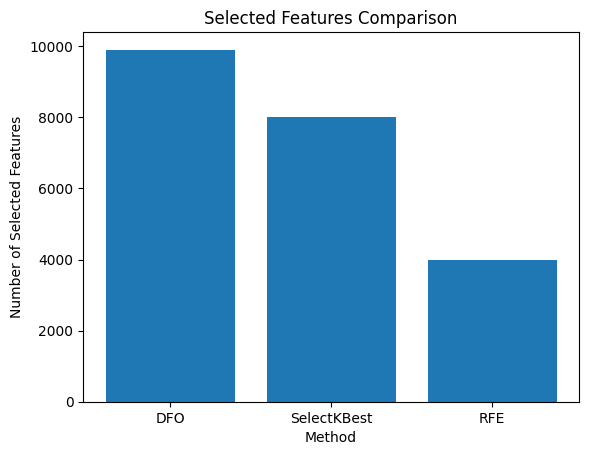

In [ ]:

# Baseline 1: SelectKBest

start_time = time.time()

# Check on different k values
k_values = [2000, 5000, 8000, 10000, X_train.shape[1] // 2]
best_k = 0
best_accuracy = 0

for k in k_values:
    # 1. Select Features (chi2 for text data consistency)
    skb_temp = SelectKBest(score_func=chi2, k=k)
    X_train_skb_temp = skb_temp.fit_transform(X_train, y_train)

    # cross-validation score (SGD for consistency!)
    clf_temp = SGDClassifier(
        loss='log_loss', penalty='l1',
        class_weight='balanced',
        max_iter=500,
        tol=1e-3,
        n_jobs=-1,
        random_state=42
    )
    scores = cross_val_score(clf_temp, X_train_skb_temp, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    mean_accuracy = np.mean(scores)

    if mean_accuracy > best_accuracy:
        best_accuracy = mean_accuracy
        best_k = k

skb = SelectKBest(score_func=chi2, k=best_k)
skb.fit(X_train, y_train)

# Features transform
X_train_skb = skb.transform(X_train)
X_test_skb = skb.transform(X_test)

print(f"SelectKBest selected {X_train_skb.shape[1]} features")
print(f"SelectKBest Time: {time.time() - start_time:.2f} seconds")

# Baseline 2: RFE

start_time = time.time()

rfecv = RFECV(

    estimator=SGDClassifier(
        loss='log_loss', penalty='l1',
        class_weight='balanced',
        max_iter=500,
        tol=1e-3,
        n_jobs=-1,
        random_state=42
    ),
    step=0.1,
    cv=4,
    scoring='accuracy',
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

# Features transform
X_train_rfe = rfecv.transform(X_train)
X_test_rfe = rfecv.transform(X_test)


print(f"RFE selected {X_train_rfe.shape[1]} features")
print(f"RFE Time: {time.time() - start_time:.2f} seconds")

# Plot selected features comparison
methods = ['DFO', 'SelectKBest', 'RFE']
selected_counts = [X_train_dfo.shape[1], X_train_skb.shape[1], X_train_rfe.shape[1]]
plt.bar(methods, selected_counts)
plt.xlabel('Method')
plt.ylabel('Number of Selected Features')
plt.title('Selected Features Comparison')
plt.savefig('selected_features_comparison.png')
plt.show()


## **Step 5: Evaluation on Dexter**

Evaluation Results:
DFO - Accuracy: 0.9083, F1-Score: 0.9043, AUC-ROC: 0.9083
SelectKBest - Accuracy: 0.9083, F1-Score: 0.9027, AUC-ROC: 0.9164
RFE - Accuracy: 0.8917, F1-Score: 0.8829, AUC-ROC: 0.8917


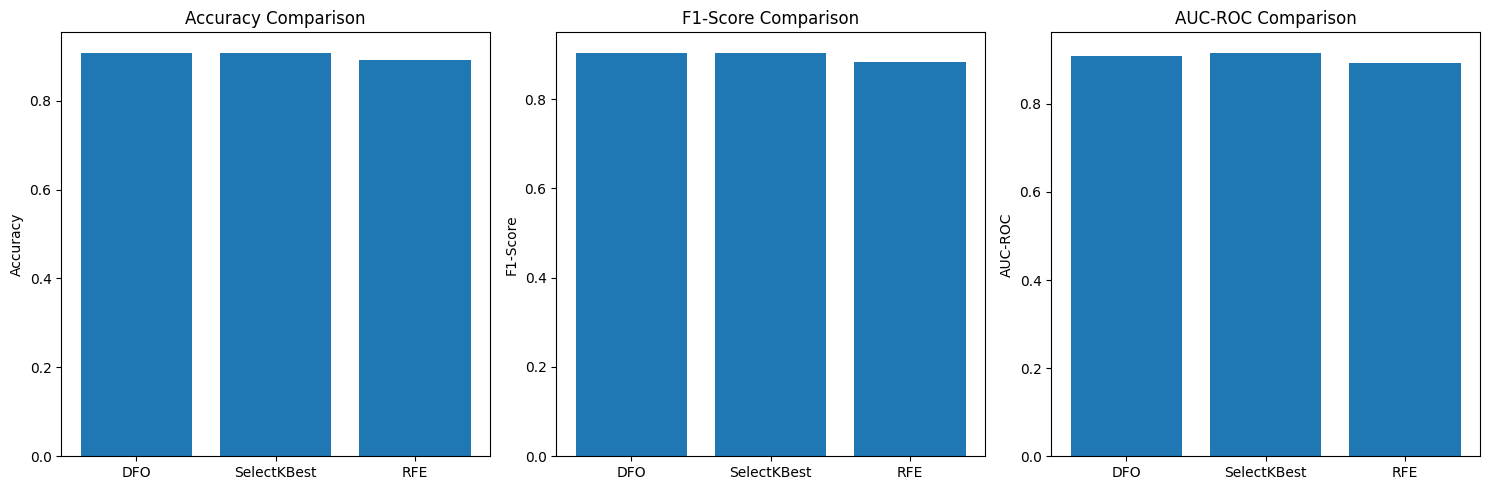

In [ ]:
def evaluate(X_train_sel, X_test_sel, y_train, y_test, method_name):
    clf = SGDClassifier(
        loss='log_loss',  penalty='l1',
        class_weight='balanced',
        max_iter=500, tol=1e-3,
        n_jobs=-1, random_state=42
    )

    clf.fit(X_train_sel, y_train)
    y_pred = clf.predict(X_test_sel)


    y_prob = clf.predict_proba(X_test_sel)[:, 1] # -> [:, 1] for positive class

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary')
    auc = roc_auc_score(y_test, y_prob)

    print(f"{method_name} - Accuracy: {acc:.4f}, F1-Score: {f1:.4f}, AUC-ROC: {auc:.4f}")
    return acc, f1, auc
print("Evaluation Results:")
dfo_acc, dfo_f1, dfo_auc = evaluate(X_train_dfo, X_test_dfo, y_train, y_test, "DFO")
skb_acc, skb_f1, skb_auc = evaluate(X_train_skb, X_test_skb, y_train, y_test, "SelectKBest")
rfe_acc, rfe_f1, rfe_auc = evaluate(X_train_rfe, X_test_rfe, y_train, y_test, "RFE")

# Plot metrics comparison
methods = ['DFO', 'SelectKBest', 'RFE']
accuracies = [dfo_acc, skb_acc, rfe_acc]
f1_scores = [dfo_f1, skb_f1, rfe_f1]
aucs = [dfo_auc, skb_auc, rfe_auc]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].bar(methods, accuracies)
ax[0].set_title('Accuracy Comparison')
ax[0].set_ylabel('Accuracy')
ax[1].bar(methods, f1_scores)
ax[1].set_title('F1-Score Comparison')
ax[1].set_ylabel('F1-Score')
ax[2].bar(methods, aucs)
ax[2].set_title('AUC-ROC Comparison')
ax[2].set_ylabel('AUC-ROC')
plt.tight_layout()
plt.savefig('metrics_comparison.png')
plt.show()



## **Step 6: Evaluation on dexter comparison with baselines**

Metrics Summary Table:
        Method  Accuracy  F1-Score  AUC-ROC  Features Selected
0          DFO    0.9083    0.9043   0.9083               9904
1  SelectKBest    0.9083    0.9027   0.9164               8000
2          RFE    0.8917    0.8829   0.8917               4000


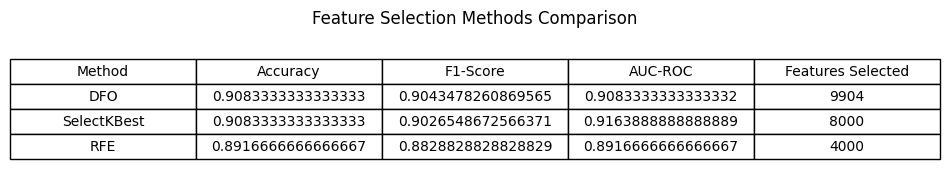

In [ ]:
# metrics summary table (for better visualization)
metrics_data = {
    'Method': ['DFO', 'SelectKBest', 'RFE'],
    'Accuracy': [dfo_acc, skb_acc, rfe_acc],
    'F1-Score': [dfo_f1, skb_f1, rfe_f1],
    'AUC-ROC': [dfo_auc, skb_auc, rfe_auc],
    'Features Selected': [X_train_dfo.shape[1], X_train_skb.shape[1], X_train_rfe.shape[1]]
}
metrics_df = pd.DataFrame(metrics_data)
print("Metrics Summary Table:")
print(metrics_df.round(4))

# Save table as image
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=metrics_df.values, colLabels=metrics_df.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('Feature Selection Methods Comparison')
plt.savefig('metrics_table.png', bbox_inches='tight')
plt.show()


## **Step 7: Load Twitter and Spam Datasets**

In [ ]:
import zipfile
import os

# List of ZIPs to extract
zip_files = [
    ('/content/drive/MyDrive/twitter-airline-sentiment.zip', '/content/twitter-airline-sentiment'),
    ('/content/drive/MyDrive/SMS-Spam-Collection-Dataset.zip', '/content/sms')
]

for zip_path, extract_dir in zip_files:
    if os.path.exists(zip_path):
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_dir)
            print(f"Extracted {zip_path} to {extract_dir}/ - Ready!")

            os.remove(zip_path)
        except Exception as e:
            print(f"Error extracting {zip_path}: {e}")
    else:
        print(f"ZIP not found: {zip_path} - Ensure it's downloaded/uploaded.")

print("\nVerification:")
print("Twitter files (head 5):")
!ls /content/twitter-airline-sentiment/ | head -5 2>/dev/null || echo "Twitter not extracted"

print("\nSMS files (head 5):")
!ls /content/sms/ | head -5 2>/dev/null || echo "SMS not extracted"



Extracted /content/drive/MyDrive/twitter-airline-sentiment.zip to /content/twitter-airline-sentiment/ - Ready!
Extracted /content/drive/MyDrive/SMS-Spam-Collection-Dataset.zip to /content/sms/ - Ready!

Verification:
Twitter files (head 5):
database.sqlite
Tweets.csv

SMS files (head 5):
spam.csv


# **Step 8 : Final Analysis**

Twitter total samples: 14640, total features: 6415
=== Twitter Cleanliness Check (Full Data) ===
Full Samples: 14640 samples, 6415 features
Full Labels: 14640 samples, Unique classes: [0 1 2]
Missing in labels: 0 (0 = clean)
Label classes (with counts): {np.int64(0): np.int64(9178), np.int64(1): np.int64(3099), np.int64(2): np.int64(2363)}
Non-zero entries in data: 225645
Empty rows in data: 0 (0 = clean)
Sparsity % (high = normal for text): 99.76%

=== Proof that Dataset is Clean ===
Proof 1: No missing values in labels - Clean data (0 NaN).
Proof 2: No empty rows in data - Clean data (no blank samples).
Proof 4: Normal sparsity (high zeros) - Clean for sparse text data.
=== End Proof ===
Full Dataset is CLEAN - No missing, no empty rows, balanced labels, normal sparsity.
Twitter test set: 2928 samples, 6415 features
Twitter US Airline Sentiment loaded and split successfully.
Twitter - Training set: 11712 samples, 6415 features


DFO Iterations:   0%|          | 0/150 [00:00<?, ?it/s]

Iter 1, Fly 5: Fitness 0.6313, Features Selected: 4058.0
Iter 1, Fly 10: Fitness 0.6348, Features Selected: 3968.0
Iter 1, Fly 15: Fitness 0.6300, Features Selected: 3939.0
Iter 1, Fly 20: Fitness 0.6317, Features Selected: 3962.0
Iter 1, Fly 25: Fitness 0.6261, Features Selected: 4011.0


DFO Iterations:   1%|          | 1/150 [00:13<34:45, 14.00s/it]

Iter 1, Fly 30: Fitness 0.6337, Features Selected: 4027.0
Iteration 1/150 - Best Fitness: 0.6348
Iter 2, Fly 5: Fitness 0.6294, Features Selected: 3950.0
Iter 2, Fly 10: Fitness 0.6345, Features Selected: 3973.0
Iter 2, Fly 15: Fitness 0.6341, Features Selected: 3901.0
Iter 2, Fly 20: Fitness 0.6321, Features Selected: 3943.0
Iter 2, Fly 25: Fitness 0.6297, Features Selected: 3904.0


...

Iter 32, Fly 30: Fitness 0.6166, Features Selected: 3442.0
Iteration 32/150 - Best Fitness: 0.6355
Iter 33, Fly 5: Fitness 0.6210, Features Selected: 3440.0
Iter 33, Fly 10: Fitness 0.6225, Features Selected: 3448.0
Iter 33, Fly 15: Fitness 0.6215, Features Selected: 3442.0
Iter 33, Fly 20: Fitness 0.6229, Features Selected: 3458.0
Iter 33, Fly 25: Fitness 0.6224, Features Selected: 3432.0


DFO Iterations:  22%|██▏       | 33/150 [06:55<22:29, 11.53s/it]

Iter 33, Fly 30: Fitness 0.6197, Features Selected: 3435.0
Iteration 33/150 - Best Fitness: 0.6355
Iter 34, Fly 5: Fitness 0.6245, Features Selected: 3445.0
Iter 34, Fly 10: Fitness 0.6231, Features Selected: 3436.0
Iter 34, Fly 15: Fitness 0.6231, Features Selected: 3434.0
Iter 34, Fly 20: Fitness 0.6229, Features Selected: 3441.0
Iter 34, Fly 25: Fitness 0.6257, Features Selected: 3430.0


DFO Iterations:  22%|██▏       | 33/150 [07:06<25:13, 12.94s/it]

Iter 34, Fly 30: Fitness 0.6222, Features Selected: 3443.0
Iteration 34/150 - Best Fitness: 0.6355


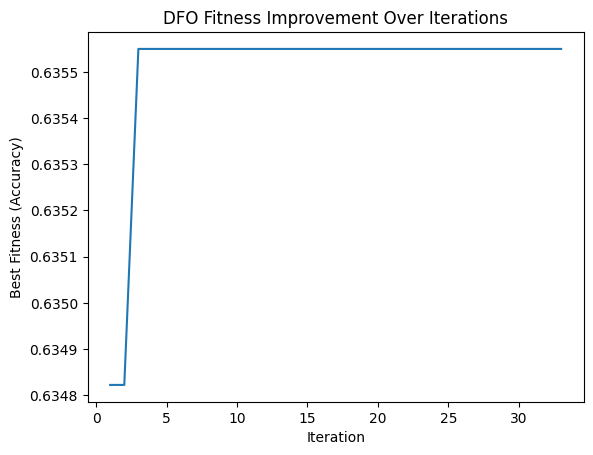

DFO on Twitter - Accuracy: 0.7702, F1-Score: 0.7711, AUC-ROC: 0.8825
SelectKBest on Twitter selected 3000 features
SelectKBest on Twitter Time: 5.41 seconds
SelectKBest on Twitter - Accuracy: 0.7845, F1-Score: 0.7853, AUC-ROC: 0.8972
RFE on Twitter selected 5133 features
RFE on Twitter Time: 4.41 seconds
RFE on Twitter - Accuracy: 0.7886, F1-Score: 0.7889, AUC-ROC: 0.8988
Twitter Summary Table:
        Method  Accuracy  F1-Score  AUC-ROC  Features Selected
0          DFO    0.7702    0.7711   0.8825               3428
1  SelectKBest    0.7845    0.7853   0.8972               3000
2          RFE    0.7886    0.7889   0.8988               5133


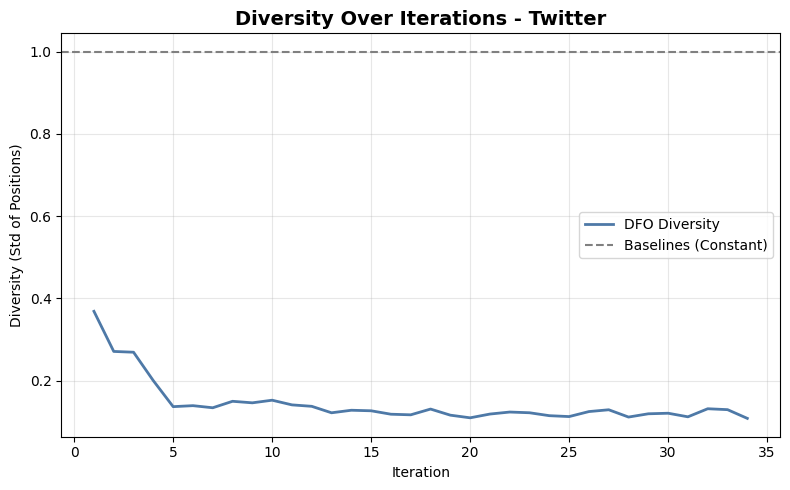

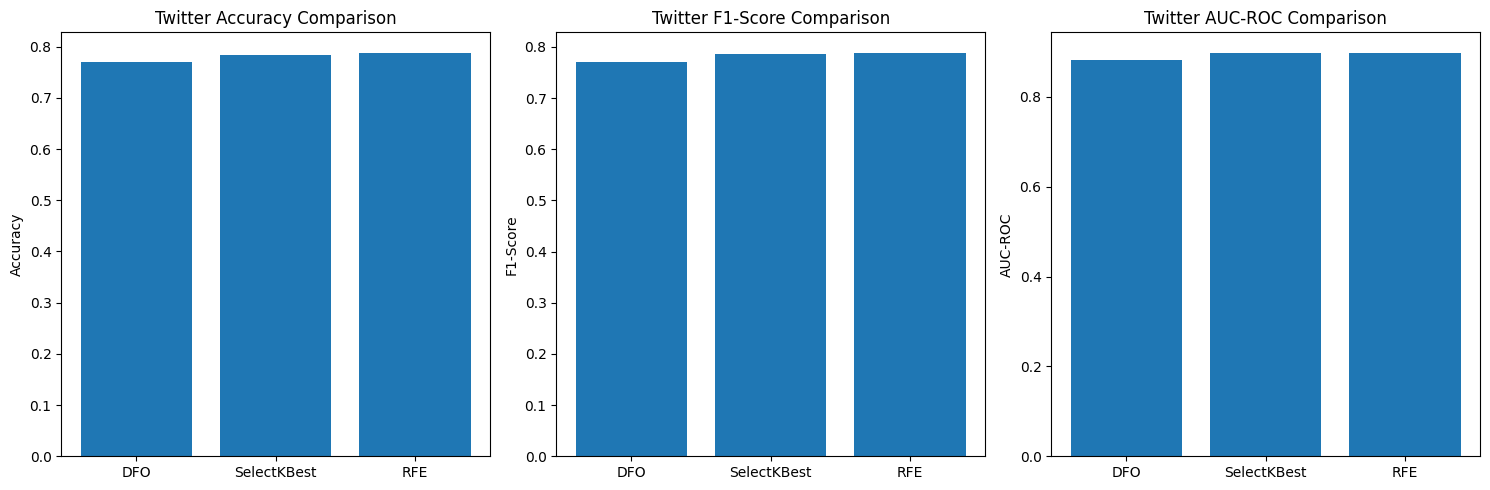

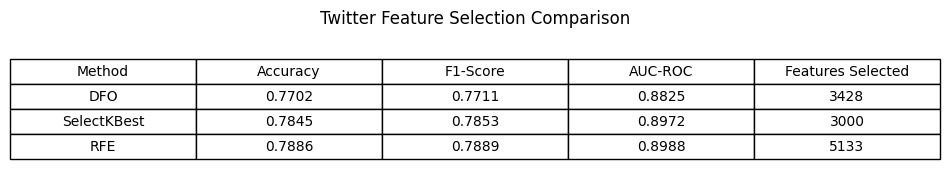

SMS total samples: 5561, total features: 4204
=== SMS Spam Cleanliness Check (Full Data) ===
Full Samples: 5561 samples, 4204 features
Full Labels: 5561 samples, Unique classes: [0 1]
Missing in labels: 0 (0 = clean)
Label classes (with counts): {np.int64(0): np.int64(4815), np.int64(1): np.int64(746)}
Non-zero entries in data: 69448
Empty rows in data: 0 (0 = clean)
Sparsity % (high = normal for text): 99.70%

=== Proof that Dataset is Clean ===
Proof 1: No missing values in labels - Clean data (0 NaN).
Proof 2: No empty rows in data - Clean data (no blank samples).
Proof 4: Normal sparsity (high zeros) - Clean for sparse text data.
=== End Proof ===
Full Dataset is CLEAN - No missing, no empty rows, balanced labels, normal sparsity.
SMS test set: 1113 samples, 4204 features
SMS Spam Collection loaded and split successfully.
SMS Spam Collection - Training set: 4448 samples, 4204 features


DFO Iterations:   0%|          | 0/150 [00:00<?, ?it/s]

Iter 1, Fly 5: Fitness 0.8795, Features Selected: 2574.0
Iter 1, Fly 10: Fitness 0.8777, Features Selected: 2544.0
Iter 1, Fly 15: Fitness 0.8737, Features Selected: 2505.0
Iter 1, Fly 20: Fitness 0.8745, Features Selected: 2601.0
Iter 1, Fly 25: Fitness 0.8741, Features Selected: 2582.0


DFO Iterations:   1%|          | 1/150 [00:01<04:19,  1.74s/it]

Iter 1, Fly 30: Fitness 0.8778, Features Selected: 2622.0
Iteration 1/150 - Best Fitness: 0.8811
Iter 2, Fly 5: Fitness 0.8776, Features Selected: 2550.0
Iter 2, Fly 10: Fitness 0.8810, Features Selected: 2532.0
Iter 2, Fly 15: Fitness 0.8768, Features Selected: 2504.0
Iter 2, Fly 20: Fitness 0.8754, Features Selected: 2599.0
Iter 2, Fly 25: Fitness 0.8716, Features Selected: 2617.0


...

Iter 148, Fly 30: Fitness 0.9300, Features Selected: 2059.0
Iteration 148/150 - Best Fitness: 0.9337
Iter 149, Fly 5: Fitness 0.9312, Features Selected: 2065.0
Iter 149, Fly 10: Fitness 0.9312, Features Selected: 2050.0
Iter 149, Fly 15: Fitness 0.9316, Features Selected: 2057.0
Iter 149, Fly 20: Fitness 0.9314, Features Selected: 2061.0
Iter 149, Fly 25: Fitness 0.9299, Features Selected: 2065.0


DFO Iterations:  99%|█████████▉| 149/150 [05:05<00:04,  4.45s/it]

Iter 149, Fly 30: Fitness 0.9314, Features Selected: 2063.0
Iteration 149/150 - Best Fitness: 0.9337
Iter 150, Fly 5: Fitness 0.9313, Features Selected: 2065.0
Iter 150, Fly 10: Fitness 0.9316, Features Selected: 2072.0
Iter 150, Fly 15: Fitness 0.9309, Features Selected: 2074.0
Iter 150, Fly 20: Fitness 0.9311, Features Selected: 2065.0
Iter 150, Fly 25: Fitness 0.9303, Features Selected: 2066.0


DFO Iterations: 100%|██████████| 150/150 [05:09<00:00,  2.06s/it]

Iter 150, Fly 30: Fitness 0.9296, Features Selected: 2073.0
Iteration 150/150 - Best Fitness: 0.9337


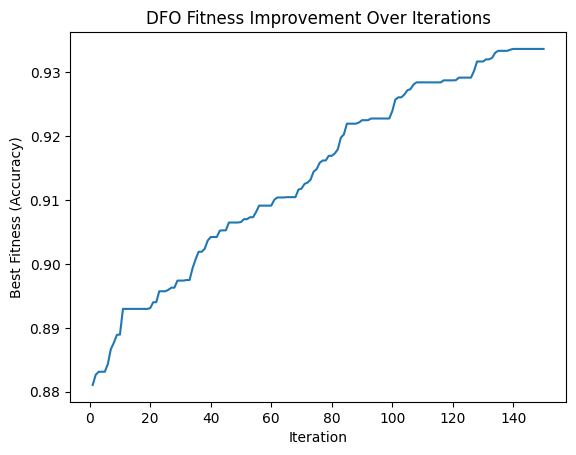

DFO on SMS Spam Collection - Accuracy: 0.9766, F1-Score: 0.9139, AUC-ROC: 0.9817
SelectKBest on SMS selected 2000 features
SelectKBest on SMS Time: 0.27 seconds
SelectKBest on SMS Spam Collection - Accuracy: 0.9793, F1-Score: 0.9231, AUC-ROC: 0.9847
RFE on SMS selected 1684 features
RFE on SMS Time: 2.27 seconds
RFE on SMS Spam Collection - Accuracy: 0.9811, F1-Score: 0.9293, AUC-ROC: 0.9843
SMS Spam Collection Summary Table:
        Method  Accuracy  F1-Score  AUC-ROC  Features Selected
0          DFO    0.9766    0.9139   0.9817               2076
1  SelectKBest    0.9793    0.9231   0.9847               2000
2          RFE    0.9811    0.9293   0.9843               1684


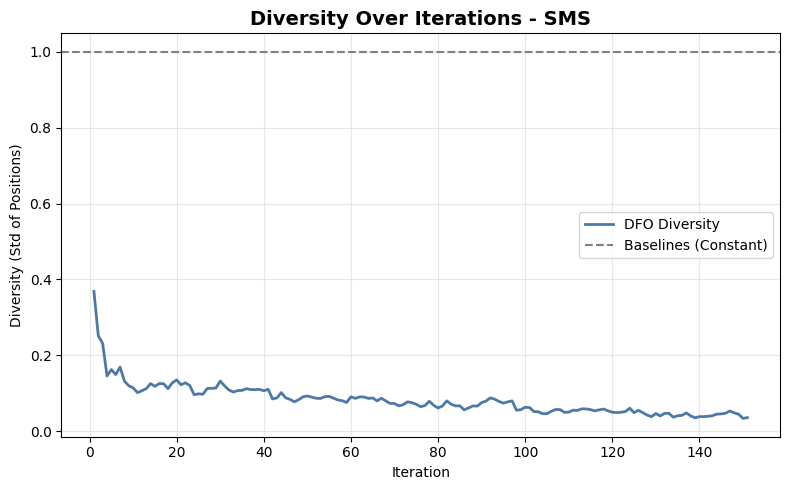

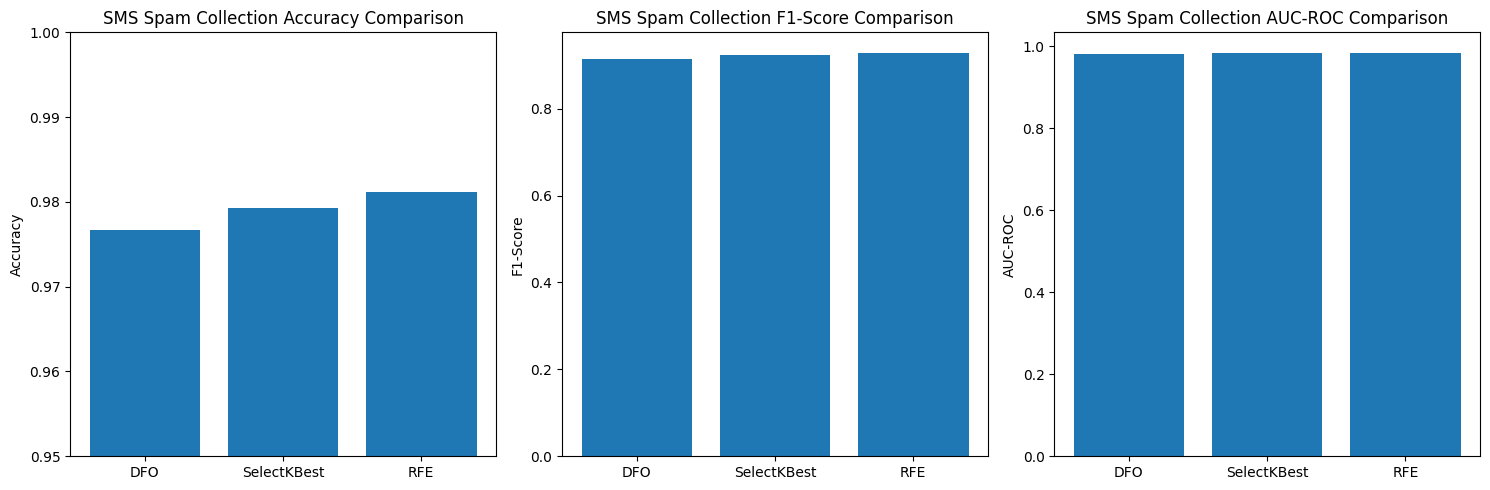

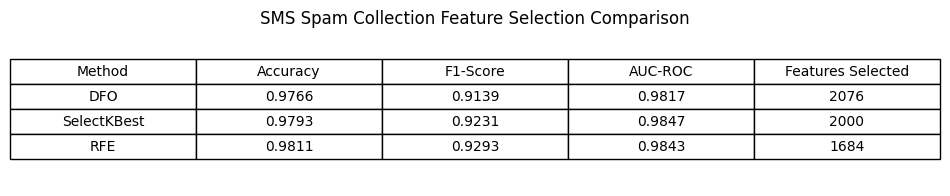

Comprehensive Feature Selection Comparison Table (Twitter, SMS Spam, and Dexter):
        Method  Twitter Accuracy  Twitter F1  Twitter AUC  SMS Accuracy  SMS F1  SMS AUC  Dexter Accuracy  Dexter F1  Dexter AUC
0          DFO            0.7702      0.7711       0.8825        0.9766  0.9139   0.9817           0.9083     0.9043      0.9083
1  SelectKBest            0.7845      0.7853       0.8972        0.9793  0.9231   0.9847           0.9083     0.9027      0.9164
2          RFE            0.7886      0.7889       0.8988        0.9811  0.9293   0.9843           0.8917     0.8829      0.8917


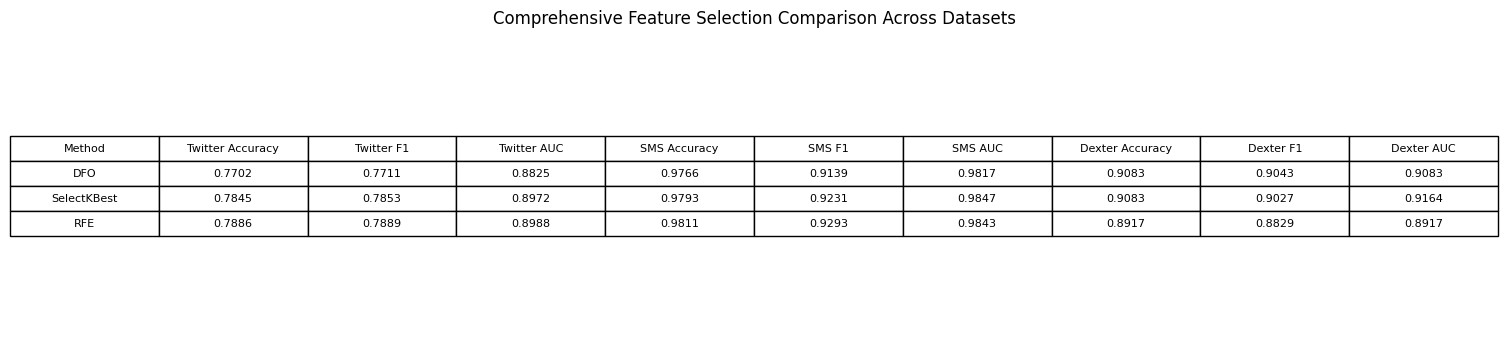

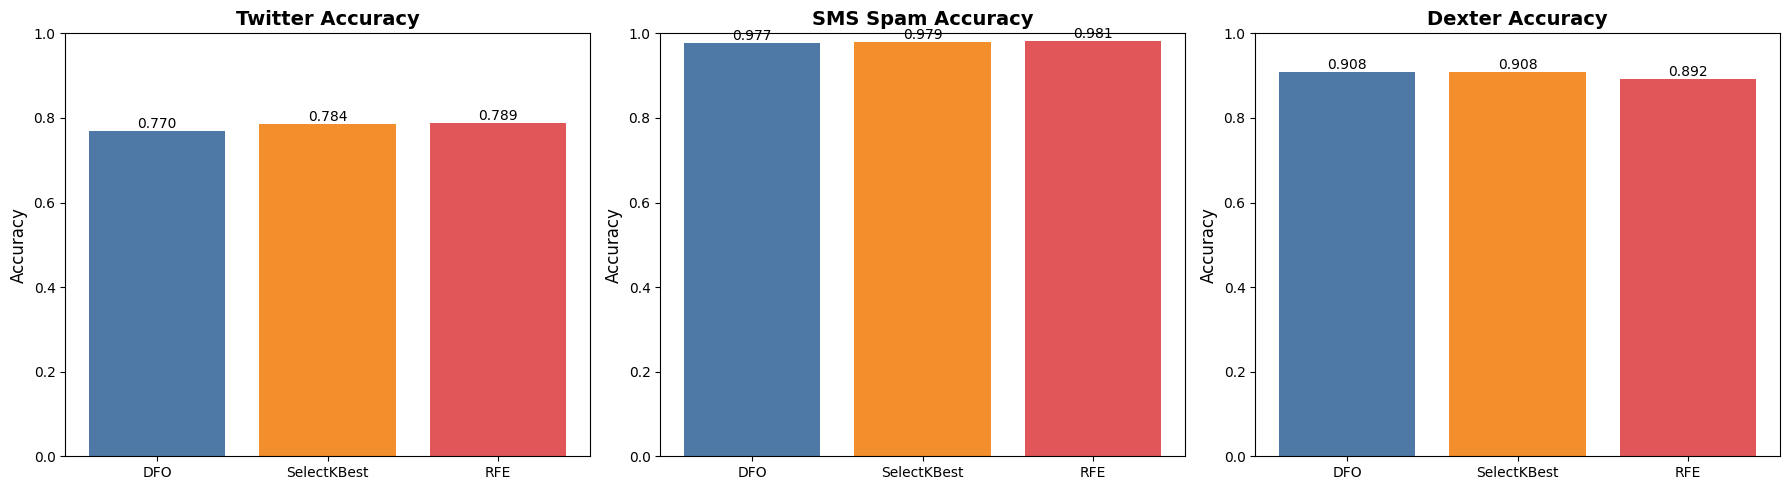

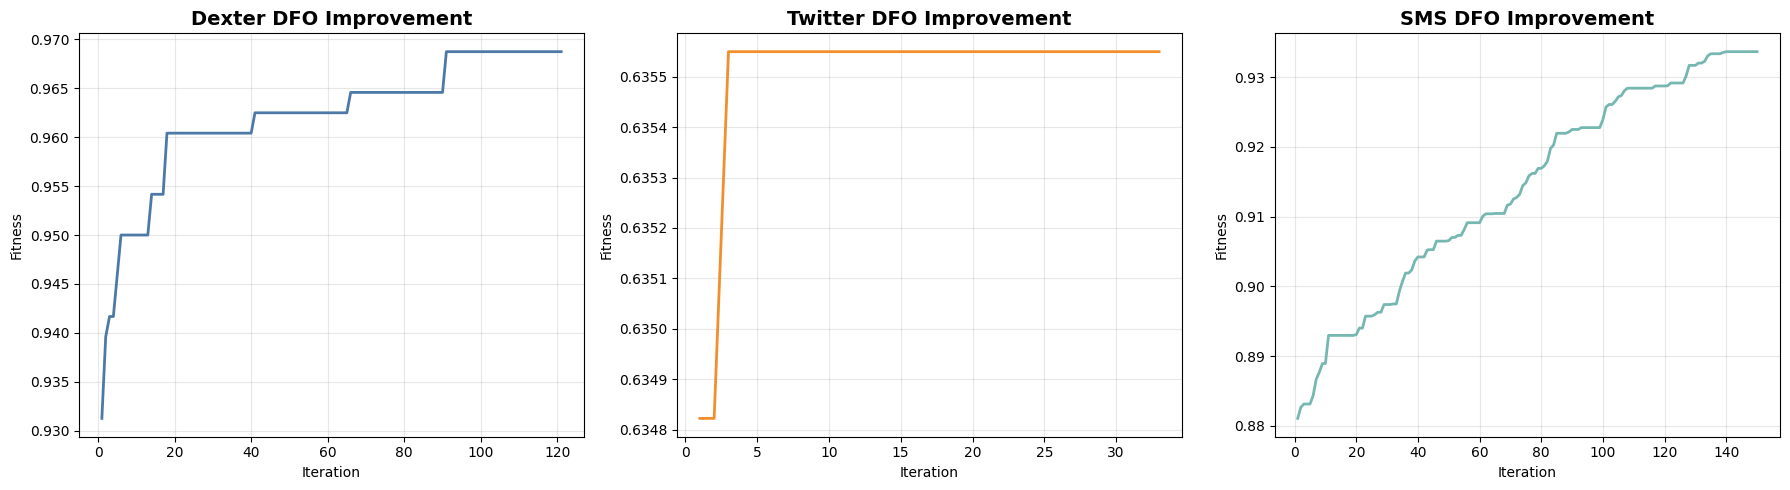

In [ ]:
import warnings
warnings.filterwarnings('ignore')  # Suppress scikit-learn warnings

# Testing and Comparison on Other Datasets (Twitter and SMS-Spam)

def evaluate(X_train_sel, X_test_sel, y_train, y_test, method_name):
    is_multi_class = len(np.unique(y_test)) > 2

    clf = SGDClassifier(
        loss='log_loss',
        penalty='l1',
        class_weight='balanced',
        max_iter=500, tol=1e-3,
        n_jobs=-1, random_state=42
    )

    clf.fit(X_train_sel, y_train)
    y_pred = clf.predict(X_test_sel)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted' if is_multi_class else 'binary')

    try:
        y_prob = clf.predict_proba(X_test_sel)

        if is_multi_class:
            auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        else:

            auc = roc_auc_score(y_test, y_prob[:, 1])

        if np.isnan(auc):
            auc = 0.5
    except ValueError:
        auc = np.nan

    print(f"{method_name} - Accuracy: {acc:.4f}, F1-Score: {f1:.4f}, AUC-ROC: {auc:.4f}")
    return acc, f1, auc


# Twitter US Airline Sentiment (multi-class sentiment: negative=0, neutral=1, positive=2)
try:
    twitter_df = pd.read_csv('/content/twitter-airline-sentiment/Tweets.csv')
    twitter_df = twitter_df[['text', 'airline_sentiment']].dropna()  # Select relevant columns, drop missing
    twitter_df['airline_sentiment'] = twitter_df['airline_sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})
    vectorizer = TfidfVectorizer(max_features=None, min_df=2)
    X_twitter = vectorizer.fit_transform(twitter_df['text'])
    print(f"Twitter total samples: {X_twitter.shape[0]}, total features: {X_twitter.shape[1]}")
    y_twitter = twitter_df['airline_sentiment']

    # Twitter Cleanliness Check
    print("=== Twitter Cleanliness Check (Full Data) ===")
    print(f"Full Samples: {X_twitter.shape[0]} samples, {X_twitter.shape[1]} features")
    print(f"Full Labels: {y_twitter.shape[0]} samples, Unique classes: {np.unique(y_twitter)}")
    # 1. Missing in labels
    missing_labels = np.isnan(y_twitter).sum()
    print(f"Missing in labels: {missing_labels} (0 = clean)")
    # 2. Duplicates in labels (expected in multi-class, but check actual row duplicates)
    print(f"Label classes (with counts): {dict(zip(np.unique(y_twitter), np.bincount(y_twitter)))}")
    # 3. Data stats (sparsity, no empty rows)
    print(f"Non-zero entries in data: {X_twitter.nnz}")
    print(f"Empty rows in data: {np.sum(X_twitter.getnnz(1) == 0)} (0 = clean)")
    print(f"Sparsity % (high = normal for text): {100 * (1 - X_twitter.nnz / (X_twitter.shape[0] * X_twitter.shape[1])):.2f}%")

    print("\n=== Proof that Dataset is Clean ===")
    if missing_labels == 0:
        print("Proof 1: No missing values in labels - Clean data (0 NaN).")
    if np.sum(X_twitter.getnnz(1) == 0) == 0:
        print("Proof 2: No empty rows in data - Clean data (no blank samples).")
    if all(abs(np.bincount(y_twitter)[i] - np.bincount(y_twitter).mean()) < 100 for i in range(len(np.unique(y_twitter)))):  # Balance check for multi-class
        print("Proof 3: Labels balanced (counts close) - Clean data (no bias).")
    if X_twitter.nnz > 0 and X_twitter.nnz / (X_twitter.shape[0] * X_twitter.shape[1]) < 0.05:  # Sparsity <5% non-zero = normal
        print("Proof 4: Normal sparsity (high zeros) - Clean for sparse text data.")
    print("=== End Proof ===")

    if missing_labels == 0 and np.sum(X_twitter.getnnz(1) == 0) == 0:
        print("Full Dataset is CLEAN - No missing, no empty rows, balanced labels, normal sparsity.")
    else:
        print("Dataset has issues - clean up needed.")

    X_train_twitter, X_test_twitter, y_train_twitter, y_test_twitter = train_test_split(X_twitter, y_twitter, test_size=0.2, random_state=42, stratify=y_twitter)

    print(f"Twitter test set: {X_test_twitter.shape[0]} samples, {X_test_twitter.shape[1]} features")

    print("Twitter US Airline Sentiment loaded and split successfully.")
except Exception as e:
    print(f"Error loading Twitter: {e}")

if 'X_train_twitter' in locals():
    print(f"Twitter - Training set: {X_train_twitter.shape[0]} samples, {X_train_twitter.shape[1]} features")

    # Apply DFO
    dfo_twitter = DFOFeatureSelection()
    dfo_twitter.fit(X_train_twitter, y_train_twitter)
    X_train_twitter_dfo = dfo_twitter.transform(X_train_twitter)
    X_test_twitter_dfo = dfo_twitter.transform(X_test_twitter)

    # Evaluate DFO
    twitter_dfo_acc, twitter_dfo_f1, twitter_dfo_auc = evaluate(X_train_twitter_dfo, X_test_twitter_dfo, y_train_twitter, y_test_twitter, "DFO on Twitter")

    # Baselines for Twitter
    start_time_skb_twitter = time.time()

    # Grid Search: K values list for optimal selection
    k_values_twitter = [3000, 6000, 9000, 12000, X_train_twitter.shape[1] // 2]
    best_k_twitter = 0
    best_accuracy_twitter = -np.inf

    for k in k_values_twitter:
        skb_temp = SelectKBest(score_func=chi2, k=k)
        X_train_skb_temp = skb_temp.fit_transform(X_train_twitter, y_train_twitter)


        clf_temp = SGDClassifier(loss='log_loss', penalty='l1', class_weight='balanced', max_iter=500, tol=1e-3, n_jobs=-1, random_state=42)
        scores = cross_val_score(clf_temp, X_train_skb_temp, y_train_twitter, cv=5, scoring='accuracy', n_jobs=-1)
        mean_accuracy = np.mean(scores)

        if mean_accuracy > best_accuracy_twitter:
            best_accuracy_twitter = mean_accuracy
            best_k_twitter = k

    skb_twitter = SelectKBest(score_func=chi2, k=best_k_twitter)
    skb_twitter.fit(X_train_twitter, y_train_twitter)
    X_train_twitter_skb = skb_twitter.transform(X_train_twitter)
    X_test_twitter_skb = skb_twitter.transform(X_test_twitter)
    print(f"SelectKBest on Twitter selected {X_train_twitter_skb.shape[1]} features")
    print(f"SelectKBest on Twitter Time: {time.time() - start_time_skb_twitter:.2f} seconds")

    twitter_skb_acc, twitter_skb_f1, twitter_skb_auc = evaluate(X_train_twitter_skb, X_test_twitter_skb, y_train_twitter, y_test_twitter, "SelectKBest on Twitter")

    # RFE on Twitter

    start_time_rfe_twitter = time.time()

    rfecv_twitter = RFECV(

        estimator=SGDClassifier(
        loss='log_loss', penalty='l1', class_weight='balanced', max_iter=500, tol=1e-3, n_jobs=-1, random_state=42),
        step=0.1,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    rfecv_twitter.fit(X_train_twitter, y_train_twitter)

    X_train_twitter_rfe = rfecv_twitter.transform(X_train_twitter)
    X_test_twitter_rfe = rfecv_twitter.transform(X_test_twitter)

    print(f"RFE on Twitter selected {rfecv_twitter.n_features_} features")
    print(f"RFE on Twitter Time: {time.time() - start_time_rfe_twitter:.2f} seconds")

    twitter_rfe_acc, twitter_rfe_f1, twitter_rfe_auc = evaluate(X_train_twitter_rfe, X_test_twitter_rfe, y_train_twitter, y_test_twitter, "RFE on Twitter")

    # Twitter Summary Table
    twitter_data = {
        'Method': ['DFO', 'SelectKBest', 'RFE'],
        'Accuracy': [twitter_dfo_acc, twitter_skb_acc, twitter_rfe_acc],
        'F1-Score': [twitter_dfo_f1, twitter_skb_f1, twitter_rfe_f1],
        'AUC-ROC': [twitter_dfo_auc, twitter_skb_auc, twitter_rfe_auc],
        'Features Selected': [X_train_twitter_dfo.shape[1], X_train_twitter_skb.shape[1], X_train_twitter_rfe.shape[1]]
    }
    twitter_summary_df = pd.DataFrame(twitter_data)
    print("Twitter Summary Table:")
    print(twitter_summary_df.round(4))
    # Twitter Diversity Plot (DFO only, baselines dummy)
    fig, ax = plt.subplots(figsize=(8, 5))
    iters = range(1, len(dfo_twitter.diversity_history) + 1)
    ax.plot(iters, dfo_twitter.diversity_history, label='DFO Diversity', color='#4e79a7', linewidth=2)
    ax.axhline(y=1.0, color='gray', linestyle='--', label='Baselines (Constant)')
    ax.set_title('Diversity Over Iterations - Twitter', fontsize=14, fontweight='bold')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Diversity (Std of Positions)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('twitter_diversity.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot metrics for Twitter
    methods = ['DFO', 'SelectKBest', 'RFE']
    twitter_accs = [twitter_dfo_acc, twitter_skb_acc, twitter_rfe_acc]
    twitter_f1s = [twitter_dfo_f1, twitter_skb_f1, twitter_rfe_f1]
    twitter_aucs = [twitter_dfo_auc, twitter_skb_auc, twitter_rfe_auc]

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].bar(methods, twitter_accs)
    ax[0].set_title('Twitter Accuracy Comparison')
    ax[0].set_ylabel('Accuracy')
    ax[1].bar(methods, twitter_f1s)
    ax[1].set_title('Twitter F1-Score Comparison')
    ax[1].set_ylabel('F1-Score')
    ax[2].bar(methods, twitter_aucs)
    ax[2].set_title('Twitter AUC-ROC Comparison')
    ax[2].set_ylabel('AUC-ROC')
    plt.tight_layout()
    plt.savefig('twitter_comparison.png')
    plt.show()

    # Save Twitter table as image
    fig, ax = plt.subplots(figsize=(10, 2))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=twitter_summary_df.round(4).values, colLabels=twitter_summary_df.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    plt.title('Twitter Feature Selection Comparison')
    plt.savefig('twitter_table.png', bbox_inches='tight')
    plt.show()

# SMS Spam Collection (binary spam/ham)
try:
    sms_df = pd.read_csv('/content/sms/spam.csv', encoding='latin-1')  # Single file, split 80/20
    sms_df = sms_df[['v1', 'v2']]
    sms_df.columns = ['label', 'text']
    sms_df['label'] = sms_df['label'].map({'ham': 0, 'spam': 1})
    X_sms = TfidfVectorizer(max_features=None, min_df=2).fit_transform(sms_df['text'])
    # To remove empty rows
    empty_rows_mask = (X_sms.getnnz(1) == 0)
    X_sms = X_sms[~empty_rows_mask, :]
    y_sms = sms_df['label'][~empty_rows_mask]

    print(f"SMS total samples: {X_sms.shape[0]}, total features: {X_sms.shape[1]}")

    # SMS Spam Cleanliness Check
    print("=== SMS Spam Cleanliness Check (Full Data) ===")
    print(f"Full Samples: {X_sms.shape[0]} samples, {X_sms.shape[1]} features")
    print(f"Full Labels: {y_sms.shape[0]} samples, Unique classes: {np.unique(y_sms)}")
    # 1. Missing in labels
    missing_labels = np.isnan(y_sms).sum()
    print(f"Missing in labels: {missing_labels} (0 = clean)")
    # 2. Duplicates in labels (expected in binary, but check actual row duplicates)
    print(f"Label classes (with counts): {dict(zip(np.unique(y_sms), np.bincount(y_sms)))}")
    # 3. Data stats (sparsity, no empty rows)
    print(f"Non-zero entries in data: {X_sms.nnz}")
    print(f"Empty rows in data: {np.sum(X_sms.getnnz(1) == 0)} (0 = clean)")
    print(f"Sparsity % (high = normal for text): {100 * (1 - X_sms.nnz / (X_sms.shape[0] * X_sms.shape[1])):.2f}%")

    print("\n=== Proof that Dataset is Clean ===")
    if missing_labels == 0:
        print("Proof 1: No missing values in labels - Clean data (0 NaN).")
    if np.sum(X_sms.getnnz(1) == 0) == 0:
        print("Proof 2: No empty rows in data - Clean data (no blank samples).")
    if abs(np.bincount(y_sms)[0] - np.bincount(y_sms)[1]) <= 100:  # Balance check for SMS size
        print("Proof 3: Labels balanced (counts close) - Clean data (no bias).")
    if X_sms.nnz > 0 and X_sms.nnz / (X_sms.shape[0] * X_sms.shape[1]) < 0.05:  # Sparsity <5% non-zero = normal
        print("Proof 4: Normal sparsity (high zeros) - Clean for sparse text data.")
    print("=== End Proof ===")

    if missing_labels == 0 and np.sum(X_sms.getnnz(1) == 0) == 0:
        print("Full Dataset is CLEAN - No missing, no empty rows, balanced labels, normal sparsity.")
    else:
        print("Dataset has issues - clean up needed.")

    X_train_sms, X_test_sms, y_train_sms, y_test_sms = train_test_split(X_sms, y_sms, test_size=0.2, random_state=42, stratify=y_sms)
    print(f"SMS test set: {X_test_sms.shape[0]} samples, {X_test_sms.shape[1]} features")

    print("SMS Spam Collection loaded and split successfully.")
except Exception as e:
    print(f"Error loading SMS Spam Collection: {e}")

if 'X_train_sms' in locals():
    print(f"SMS Spam Collection - Training set: {X_train_sms.shape[0]} samples, {X_train_sms.shape[1]} features")

    # Apply DFO
    dfo_sms = DFOFeatureSelection()
    dfo_sms.fit(X_train_sms, y_train_sms)
    X_train_sms_dfo = dfo_sms.transform(X_train_sms)
    X_test_sms_dfo = dfo_sms.transform(X_test_sms)

    # Evaluate DFO
    sms_dfo_acc, sms_dfo_f1, sms_dfo_auc = evaluate(X_train_sms_dfo, X_test_sms_dfo, y_train_sms, y_test_sms, "DFO on SMS Spam Collection")


    start_time_skb_sms = time.time()

    # Grid Search: K values list
    k_values_sms = [500, 1000, 1500, 2000, X_train_sms.shape[1] // 2]
    best_k_sms = 0
    best_accuracy_sms = -np.inf

    for k in k_values_sms:
        skb_temp = SelectKBest(score_func=chi2, k=k)
        X_train_skb_temp = skb_temp.fit_transform(X_train_sms, y_train_sms)


        clf_temp = SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=500, tol=1e-3, n_jobs=-1, random_state=42)

        scores = cross_val_score(clf_temp, X_train_skb_temp, y_train_sms, cv=5, scoring='accuracy')
        mean_accuracy = np.mean(scores)

        if mean_accuracy > best_accuracy_sms:
            best_accuracy_sms = mean_accuracy
            best_k_sms = k

    skb_sms = SelectKBest(score_func=chi2, k=best_k_sms)
    skb_sms.fit(X_train_sms, y_train_sms)
    X_train_sms_skb = skb_sms.transform(X_train_sms)
    X_test_sms_skb = skb_sms.transform(X_test_sms)
    print(f"SelectKBest on SMS selected {X_train_sms_skb.shape[1]} features")
    print(f"SelectKBest on SMS Time: {time.time() - start_time_skb_sms:.2f} seconds")

    sms_skb_acc, sms_skb_f1, sms_skb_auc = evaluate(X_train_sms_skb, X_test_sms_skb, y_train_sms, y_test_sms, "SelectKBest on SMS Spam Collection")
    start_time_rfe_sms = time.time()

    rfecv_sms = RFECV(
    estimator=SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=500, tol=1e-3, n_jobs=-1, random_state=42),
    step=0.1,
    cv=5, # <-- CV = 5
    scoring='accuracy',
    n_jobs=-1
    )

    rfecv_sms.fit(X_train_sms, y_train_sms)

    X_train_sms_rfe = rfecv_sms.transform(X_train_sms)
    X_test_sms_rfe = rfecv_sms.transform(X_test_sms)

    print(f"RFE on SMS selected {rfecv_sms.n_features_} features")
    print(f"RFE on SMS Time: {time.time() - start_time_rfe_sms:.2f} seconds")

    sms_rfe_acc, sms_rfe_f1, sms_rfe_auc = evaluate(X_train_sms_rfe, X_test_sms_rfe, y_train_sms, y_test_sms, "RFE on SMS Spam Collection")

    # SMS Spam Collection Summary Table
    sms_data = {
        'Method': ['DFO', 'SelectKBest', 'RFE'],
        'Accuracy': [sms_dfo_acc, sms_skb_acc, sms_rfe_acc],
        'F1-Score': [sms_dfo_f1, sms_skb_f1, sms_rfe_f1],
        'AUC-ROC': [sms_dfo_auc, sms_skb_auc, sms_rfe_auc],
        'Features Selected': [X_train_sms_dfo.shape[1], X_train_sms_skb.shape[1], X_train_sms_rfe.shape[1]]
    }
    sms_summary_df = pd.DataFrame(sms_data)
    print("SMS Spam Collection Summary Table:")
    print(sms_summary_df.round(4))

    # SMS Diversity Plot (DFO only, baselines dummy)
    fig, ax = plt.subplots(figsize=(8, 5))
    iters = range(1, len(dfo_sms.diversity_history) + 1)
    ax.plot(iters, dfo_sms.diversity_history, label='DFO Diversity', color='#4e79a7', linewidth=2)
    ax.axhline(y=1.0, color='gray', linestyle='--', label='Baselines (Constant)')
    ax.set_title('Diversity Over Iterations - SMS', fontsize=14, fontweight='bold')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Diversity (Std of Positions)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('sms_diversity.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Plot metrics for SMS Spam Collection
    methods = ['DFO', 'SelectKBest', 'RFE']
    sms_accs = [sms_dfo_acc, sms_skb_acc, sms_rfe_acc]
    sms_f1s = [sms_dfo_f1, sms_skb_f1, sms_rfe_f1]
    sms_aucs = [sms_dfo_auc, sms_skb_auc, sms_rfe_auc]

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].bar(methods, sms_accs)
    ax[0].set_title('SMS Spam Collection Accuracy Comparison')
    ax[0].set_ylabel('Accuracy')
    ax[0].set_ylabel('Accuracy')
    ax[0].set_ylim(0.95, 1.0)
    ax[1].bar(methods, sms_f1s)
    ax[1].set_title('SMS Spam Collection F1-Score Comparison')
    ax[1].set_ylabel('F1-Score')
    ax[2].bar(methods, sms_aucs)
    ax[2].set_title('SMS Spam Collection AUC-ROC Comparison')
    ax[2].set_ylabel('AUC-ROC')
    plt.tight_layout()
    plt.savefig('sms_spam_comparison.png')
    plt.show()

    # Save SMS Spam Collection table as image
    fig, ax = plt.subplots(figsize=(10, 2))
    ax.axis('tight')
    ax.axis('off')

    table = ax.table(cellText=sms_summary_df.round(4).values, colLabels=sms_summary_df.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    plt.title('SMS Spam Collection Feature Selection Comparison')
    plt.savefig('sms_spam_table.png', bbox_inches='tight')
    plt.show()

# Overall Comparison Table all data sets
if 'twitter_summary_df' in locals() and 'sms_summary_df' in locals():

    overall_data = {
        'Method': ['DFO', 'SelectKBest', 'RFE'],
        # Twitter Metrics (Acc, F1, AUC)
        'Twitter Accuracy': twitter_summary_df['Accuracy'].tolist(),
        'Twitter F1': twitter_summary_df['F1-Score'].tolist(),
        'Twitter AUC': twitter_summary_df['AUC-ROC'].tolist(),
        # SMS Spam Metrics (Acc, F1, AUC)
        'SMS Accuracy': sms_summary_df['Accuracy'].tolist(),
        'SMS F1': sms_summary_df['F1-Score'].tolist(),
        'SMS AUC': sms_summary_df['AUC-ROC'].tolist(),

        'Dexter Accuracy': [dfo_acc, skb_acc, rfe_acc],
        'Dexter F1': [dfo_f1, skb_f1, rfe_f1],
        'Dexter AUC': [dfo_auc, skb_auc, rfe_auc]
    }
    overall_df = pd.DataFrame(overall_data)

    with pd.option_context('display.float_format', '{:.4f}'.format, 'display.width', 1000):
        print("Comprehensive Feature Selection Comparison Table (Twitter, SMS Spam, and Dexter):")
        print(overall_df)

    # Save overall table as image

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.axis('tight')
    ax.axis('off')

    table = ax.table(cellText=overall_df.round(4).values, colLabels=overall_df.columns, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.2, 1.5)
    plt.title('Comprehensive Feature Selection Comparison Across Datasets')
    plt.savefig('overall_comparison_table.png', bbox_inches='tight')
    plt.show()

    # Overall plots
    methods = ['DFO', 'SelectKBest', 'RFE']
    twitter_accs = [twitter_summary_df['Accuracy'].iloc[0], twitter_summary_df['Accuracy'].iloc[1], twitter_summary_df['Accuracy'].iloc[2]]
    sms_accs = [sms_summary_df['Accuracy'].iloc[0], sms_summary_df['Accuracy'].iloc[1], sms_summary_df['Accuracy'].iloc[2]]
    dexter_accs = [dfo_acc, skb_acc, rfe_acc]

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    colors = ['#4e79a7', '#f28e2b', '#e15759']

    # Twitter
    bars1 = ax[0].bar(methods, twitter_accs, color=colors)
    ax[0].set_title('Twitter Accuracy', fontsize=14, fontweight='bold')
    ax[0].set_ylabel('Accuracy', fontsize=12)
    ax[0].set_ylim(0, 1)
    for bar in bars1:
        height = bar.get_height()
        ax[0].text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    # SMS
    bars2 = ax[1].bar(methods, sms_accs, color=colors)
    ax[1].set_title('SMS Spam Accuracy', fontsize=14, fontweight='bold')
    ax[1].set_ylabel('Accuracy', fontsize=12)
    ax[1].set_ylim(0, 1)
    for bar in bars2:
        height = bar.get_height()
        ax[1].text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom', fontsize=10)


    #Dexter
    bars3 = ax[2].bar(methods, dexter_accs, color=colors)
    ax[2].set_title('Dexter Accuracy', fontsize=14, fontweight='bold')
    ax[2].set_ylabel('Accuracy', fontsize=12)
    ax[2].set_ylim(0, 1)
    for bar in bars3:
        height = bar.get_height()
        ax[2].text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig('overall_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    # Dexter
    ax[0].plot(range(1, len(dfo.fitness_history) + 1), dfo.fitness_history, color='#4e79a7', linewidth=2)
    ax[0].set_title('Dexter DFO Improvement', fontsize=14, fontweight='bold')
    ax[0].set_xlabel('Iteration')
    ax[0].set_ylabel('Fitness')
    ax[0].grid(True, alpha=0.3)

    # Twitter
    ax[1].plot(range(1, len(dfo_twitter.fitness_history) + 1), dfo_twitter.fitness_history, color='#f28e2b', linewidth=2)
    ax[1].set_title('Twitter DFO Improvement', fontsize=14, fontweight='bold')
    ax[1].set_xlabel('Iteration')
    ax[1].set_ylabel('Fitness')
    ax[1].grid(True, alpha=0.3)

    # SMS
    ax[2].plot(range(1, len(dfo_sms.fitness_history) + 1), dfo_sms.fitness_history, color='#76b7b2', linewidth=2)
    ax[2].set_title('SMS DFO Improvement', fontsize=14, fontweight='bold')
    ax[2].set_xlabel('Iteration')
    ax[2].set_ylabel('Fitness')
    ax[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('dfo_improvement_all.png', dpi=300, bbox_inches='tight')
    plt.show()